In [1291]:
from sklearn.linear_model import LogisticRegression

In [1292]:
lr = LogisticRegression(
    max_iter=1000
)

In [1293]:
from sklearn.model_selection import train_test_split

In [1294]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_telco.csv")


In [1295]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [1296]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [1297]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [1298]:
X = df_encoded.drop(
    "Churn",
    axis=1
)

y = df_encoded["Churn"]

In [1299]:
print(X.shape)
print(y.shape)

(7043, 30)
(7043,)


In [1300]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [1301]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 30)
(1409, 30)
(5634,)
(1409,)


In [1302]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [1303]:
X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [1304]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5634, 30)
(1409, 30)


In [1305]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

In [1306]:
lr.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [1307]:
lr_pred = lr.predict(
    X_test_scaled
)

In [1308]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    lr_pred
)

print(accuracy)

0.8069552874378992


In [1309]:
dir()

['DecisionTreeClassifier',
 'In',
 'LogisticRegression',
 'Out',
 'RandomForestClassifier',
 'StandardScaler',
 'X',
 'XGBClassifier',
 'X_test',
 'X_test_scaled',
 'X_train',
 'X_train_scaled',
 '_',
 '_1001',
 '_1006',
 '_1010',
 '_1013',
 '_1014',
 '_1016',
 '_1017',
 '_1023',
 '_1034',
 '_1037',
 '_1040',
 '_1044',
 '_1049',
 '_1053',
 '_1056',
 '_1057',
 '_1059',
 '_1060',
 '_1066',
 '_1077',
 '_1080',
 '_1083',
 '_1087',
 '_1092',
 '_1096',
 '_1099',
 '_1100',
 '_1102',
 '_1103',
 '_111',
 '_1110',
 '_1121',
 '_1124',
 '_1127',
 '_1131',
 '_1136',
 '_1140',
 '_1143',
 '_1144',
 '_1146',
 '_1147',
 '_1150',
 '_1155',
 '_1166',
 '_1169',
 '_1172',
 '_1176',
 '_1181',
 '_1185',
 '_1188',
 '_1189',
 '_1191',
 '_1192',
 '_1195',
 '_1201',
 '_1212',
 '_1215',
 '_1218',
 '_1222',
 '_1227',
 '_1231',
 '_1234',
 '_1235',
 '_1237',
 '_1238',
 '_1241',
 '_1243',
 '_1248',
 '_125',
 '_1259',
 '_1262',
 '_1265',
 '_1269',
 '_1274',
 '_1278',
 '_1281',
 '_1282',
 '_1284',
 '_1285',
 '_1288',
 

In [1310]:
from sklearn.tree import DecisionTreeClassifier

In [1311]:
dt = DecisionTreeClassifier(
    random_state=42
)

In [1312]:
dt.fit(
    X_train,
    y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [1313]:
dt_pred = dt.predict(
    X_test
)

In [1314]:
from sklearn.ensemble import RandomForestClassifier

In [1315]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [1316]:
rf.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [1317]:
rf_pred = rf.predict(
    X_test
)

In [1318]:
import sys

!{sys.executable} -m pip install xgboost

In [1319]:
from xgboost import XGBClassifier

In [1320]:
xgb = XGBClassifier(
    random_state=42
)

In [1321]:
xgb.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [1322]:
xgb_pred = xgb.predict(
    X_test
)

MODAL COMPARSION


In [1323]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [1324]:
def evaluate_model(
    y_true,
    y_pred,
    model_name
):
    return {
        "Model":model_name,
        "Accuracy":accuracy_score(
            y_true,
            y_pred
        ),
        "Precision":precision_score(
            y_true,
            y_pred
        ),
        "Recall":recall_score(
            y_true,
            y_pred
        ),
        "F1":f1_score(
            y_true,
            y_pred
        )
    }

In [1325]:
results = pd.DataFrame([
    evaluate_model(
        y_test,
        lr_pred,
        "Logistic Regression"
    ),
    evaluate_model(
        y_test,
        dt_pred,
        "Decision Tree"
    ),
    evaluate_model(
        y_test,
        rf_pred,
        "Random Forest"
    ),
    evaluate_model(
        y_test,
        xgb_pred,
        "XGBoost"
    )
])

results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195
1,Decision Tree,0.741661,0.513889,0.494652,0.504087
2,Random Forest,0.789922,0.633562,0.494652,0.555556
3,XGBoost,0.784954,0.607903,0.534759,0.568990


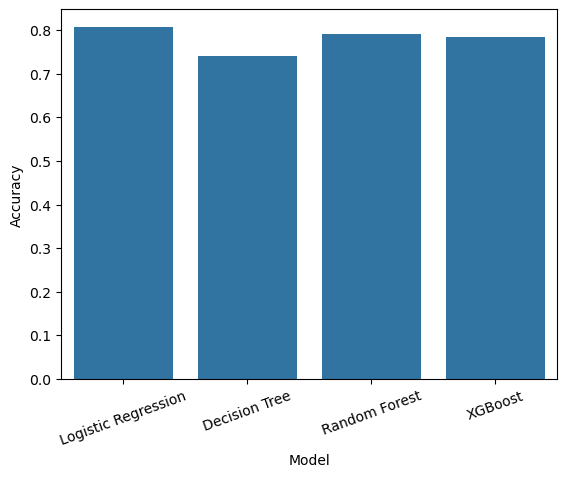

In [1326]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.xticks(rotation=20)

plt.show()

In [1327]:
import joblib


In [1328]:
joblib.dump(
    lr,
    "../models/best_model.pkl"
)

['../models/best_model.pkl']

In [1329]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [1330]:
import os

print(os.listdir("../models"))

['best_model.pkl', 'scaler.pkl']


In [1331]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

importance.head()

,Feature,Coefficient
0,SeniorCitizen,0.052901
1,tenure,-1.219639
2,MonthlyCharges,-0.921369
3,TotalCharges,0.497246
4,gender_Male,0.011110


In [1332]:
importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

importance.head(15)

,Feature,Coefficient
10,InternetService_Fiber optic,0.778760
3,TotalCharges,0.497246
23,StreamingMovies_Yes,0.258653
21,StreamingTV_Yes,0.258042
9,MultipleLines_Yes,0.216356
26,PaperlessBilling_Yes,0.181833
28,PaymentMethod_Electronic check,0.181456
17,DeviceProtection_Yes,0.053625
0,SeniorCitizen,0.052901
29,PaymentMethod_Mailed check,0.033133


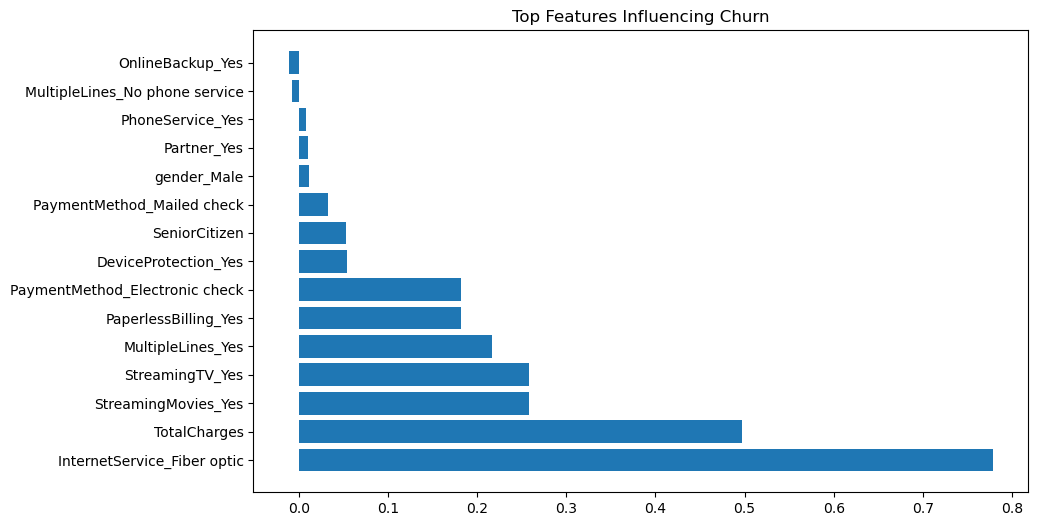

In [1333]:
import matplotlib.pyplot as plt

top_features = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Features Influencing Churn")

plt.show()

Customer Risk Score

In [1334]:
risk_scores = lr.predict_proba(
    X_test_scaled
)[:,1]

In [1335]:
risk_df = pd.DataFrame({
    "RiskScore": risk_scores
})

risk_df.head()

,RiskScore
0,0.044365
1,0.683600
2,0.056440
3,0.408306
4,0.021691


In [1336]:
risk_df["RiskLevel"] = pd.cut(
    risk_df["RiskScore"],
    bins=[0,0.3,0.7,1],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [1337]:
risk_df["RiskLevel"].value_counts()

RiskLevel
Low       865
Medium    455
High       89
Name: count, dtype: int64

Retention Recommendation Engine

In [1338]:
def retention_strategy(score):

    if score > 0.7:
        return "Offer Discount"

    elif score > 0.4:
        return "Personalized Call"

    else:
        return "No Action Needed"